#1. Introduction & Market Analysis

##1.1 Company Background

**Company A** is a telecommunications operator that provides wireless communication services to a large customer base. The company has accumulated extensive historical customer information, including demographics, service usage, billing records, equipment details, and customer behavior metrics.

Although the company possesses a large volume of data, it currently lacks advanced machine learning capabilities to extract actionable business insights. As competition in the telecommunications industry intensifies, customer retention and revenue optimization have become increasingly important.

This project aims to leverage **Company A's** customer data to identify business opportunities through data analysis and machine learning. By understanding customer behavior and predicting future outcomes, the company can make more informed decisions and improve overall business performance.

##1.2 Telecom Industry Analysis

The telecommunications industry is one of the most competitive industries worldwide. Mobile service providers continuously compete to attract and retain customers while maintaining profitability.

Customer acquisition costs are generally much higher than customer retention costs, making customer retention a critical business objective. In mature telecom markets, revenue growth often depends on increasing customer lifetime value, reducing churn, and improving customer satisfaction.

Several factors influence customer retention, including:

- Service quality
- Pricing and billing structure
- Device age and performance
- Customer support experience
- Availability of competitive alternatives

The increasing availability of customer data has enabled telecom operators to adopt data-driven strategies. Machine learning techniques can help identify customers at risk of leaving, uncover revenue opportunities, and optimize customer engagement strategies.

As a result, telecommunications companies are increasingly investing in predictive analytics and artificial intelligence solutions to improve operational efficiency and business outcomes.

##1.3 Objective

The objective of this project is to analyze customer data from Company A and identify actionable business opportunities through machine learning and data-driven decision making.

The project follows four main goals:

1. Understand customer behavior through exploratory data analysis.
2. Identify business challenges and opportunities within the customer base.
3. Develop machine learning models to support business decision making.
4. Propose a practical business solution supported by quantitative evidence.

The final outcome of this project is a business proposal that demonstrates how Company A can use data and machine learning to improve customer retention, increase revenue, and strengthen its competitive position within the telecommunications market.

#2. Data Loading

## 2.1 Importing Libraries

The following are the libraries that I will be using for data manipulation, visualization, preprocessing, machine learning, and model evaluation throughout this **Final Assignment** project.

In [ ]:
!pip install catboost

In [ ]:
# Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    StandardScaler
)

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import KNNImputer
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.impute import SimpleImputer

# Utility Settings

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
sns.set_style("whitegrid")
print("Libraries imported successfully.")

Libraries imported successfully.


##2.2 Drive Connection

Since the dataset is stored in my local Google Drive account, **Google Colaboratory** must first be connected to the this Google Drive account.

In [ ]:
# Mounting my google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##2.3 Working Directory

The project folder, **Final Assignment,** containing the dataset for Company A is located in Google Drive. The working directory is set to the project folder to simplify file access.

In [ ]:
# PATH
%cd "/content/drive/MyDrive/GCI/05. Final Assignment (due Jun 19th 11AM UTC)/Final Assignment"

/content/drive/MyDrive/GCI/05. Final Assignment (due Jun 19th 11AM UTC)/Final Assignment


##2.4 Loading Datasets

The project dataset is provided in two separate tables:

|  | File | Granularity | Contents |
|---|---|---|---|
| 1 |`Client.csv` | one row per customer | account-level info: tenure, plan, demographics, equipment |
| 2 | `Record.csv` | one row per customer | mean monthly usage, billing, and call-quality metrics, plus the `churn` target |

Both tables share a `Customer_ID` column, which we use to join them into a single analysis table.


In [ ]:
import os
from pathlib import Path

current_dir = Path(os.getcwd())
client_path = current_dir / "telecom" / "Client.csv"
record_path = current_dir / "telecom" / "Record.csv"

for p in (client_path, record_path):
    print(f"{'OK ' if p.exists() else 'MISSING '} {p}")

OK  /content/drive/MyDrive/GCI/05. Final Assignment (due Jun 19th 11AM UTC)/Final Assignment/telecom/Client.csv
OK  /content/drive/MyDrive/GCI/05. Final Assignment (due Jun 19th 11AM UTC)/Final Assignment/telecom/Record.csv


In [ ]:
client = pd.read_csv(client_path)
record = pd.read_csv(record_path)

print(f"Client: {client.shape}")
print(f"Record: {record.shape}")

Client: (100000, 50)
Record: (100000, 51)


### Dataset Preview

Before I merge the datasets, this is their current structure and contents.

In [ ]:
display(client.head())

,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev,prizm_social_one,area,dualband,refurb_new,hnd_price,phones,models,hnd_webcap,truck,rv,ownrent,lor,dwlltype,marital,adults,infobase,income,numbcars,HHstatin,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays,Customer_ID
0,2,1,U,A,N,1652,4228.00000,1504.62,1453.44,4085.00,1602,29.66,83.37,32.69,272,116,30,322.0,136.0,38.0,S,NORTHWEST/ROCKY MOUNTAIN AREA,Y,N,149.98999,2.0,2.0,WCMB,0.0,0.0,O,15.0,S,S,1.0,M,4.0,3.0,C,A,0.0,N,U,U,U,U,U,Y,361.0,1000001
1,1,1,N,EA,N,14654,26400.00000,2851.68,2833.88,26367.00,14624,51.53,479.40,265.89,305,158,40,477.0,275.0,48.0,U,CHICAGO AREA,N,N,NaN,7.0,6.0,WC,1.0,1.0,NaN,1.0,S,S,1.0,M,5.0,1.0,C,A,0.0,Z,U,U,U,U,U,Y,240.0,1000002
2,1,1,Y,C,N,7903,24385.05333,2155.91,1934.47,24303.05,7888,34.54,433.98,140.86,12,7,17,11.0,6.0,17.0,S,GREAT LAKES AREA,N,N,29.98999,2.0,1.0,NaN,0.0,0.0,O,7.0,S,M,2.0,M,5.0,2.0,C,A,0.0,N,U,Y,U,U,U,Y,1504.0,1000003
3,1,1,Y,B,N,1502,3065.00000,2000.90,1941.81,3035.00,1479,40.45,63.23,30.81,8,3,38,50.0,25.0,40.0,T,CHICAGO AREA,N,N,29.98999,1.0,1.0,NaN,0.0,0.0,NaN,6.0,M,M,4.0,M,6.0,1.0,C,D,0.0,U,Y,U,U,U,U,Y,1812.0,1000004
4,1,1,Y,A,N,4485,14028.00000,2181.12,2166.48,13965.00,4452,38.69,249.38,79.50,558,191,55,586.0,196.0,80.0,U,NEW ENGLAND AREA,Y,N,149.98999,6.0,4.0,WCMB,0.0,0.0,R,5.0,M,S,1.0,M,6.0,1.0,C,O,0.0,I,U,U,U,U,U,Y,434.0,1000005


In [ ]:
display(record.head())

,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,change_rev,drop_vce_Mean,drop_dat_Mean,blck_vce_Mean,blck_dat_Mean,unan_vce_Mean,unan_dat_Mean,plcd_vce_Mean,plcd_dat_Mean,recv_vce_Mean,recv_sms_Mean,comp_vce_Mean,comp_dat_Mean,custcare_Mean,ccrndmou_Mean,cc_mou_Mean,inonemin_Mean,threeway_Mean,mou_cvce_Mean,mou_cdat_Mean,mou_rvce_Mean,owylis_vce_Mean,mouowylisv_Mean,iwylis_vce_Mean,mouiwylisv_Mean,peak_vce_Mean,peak_dat_Mean,mou_peav_Mean,mou_pead_Mean,opk_vce_Mean,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months,Customer_ID
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,-18.9975,0.666667,0.0,0.666667,0.0,6.333333,0.0,52.333333,0.0,42.333333,0.0,45.000000,0.0,0.000000,0.000000,0.000000,18.000000,0.000000,90.643333,0.0,97.176667,0.000000,0.000000,0.000000,0.000000,58.000000,0.0,132.600000,0.0,24.000000,0.0,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61,1000001
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,50.9875,8.333333,0.0,1.000000,0.0,61.333333,0.0,263.333333,0.0,69.000000,0.0,193.333333,0.0,1.666667,6.333333,5.463333,53.000000,0.333333,189.396667,0.0,55.280000,46.333333,24.216667,6.333333,3.696667,83.666667,0.0,75.333333,0.0,157.000000,0.0,169.343333,0.0,9.333333,263.333333,193.333333,0.0,5.666667,0,56,1000002
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,0.0000,0.333333,0.0,0.000000,0.0,2.666667,0.0,9.000000,0.0,0.333333,0.0,6.000000,0.0,0.000000,0.000000,0.000000,0.333333,0.000000,5.426667,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.0,5.193333,0.0,1.000000,0.0,0.233333,0.0,0.333333,9.000000,6.000000,0.0,0.000000,1,58,1000003
3,38.0000,7.50,38.000,0.0000,0.00,0.0,0.0,0.0,0.0,-1.50,0.0000,0.000000,0.0,0.000000,0.0,0.000000,0.0,3.666667,0.0,1.333333,0.0,3.666667,0.0,0.000000,0.000000,0.000000,1.333333,0.000000,8.410000,0.0,0.413333,0.333333,0.256667,0.000000,0.000000,1.333333,0.0,3.380000,0.0,3.666667,0.0,5.450000,0.0,0.000000,3.666667,3.666667,0.0,0.000000,0,60,1000004
4,55.2300,570.50,71.980,0.0000,0.00,0.0,0.0,0.0,0.0,38.50,0.0000,9.666667,0.0,0.666667,0.0,77.000000,0.0,222.333333,0.0,94.666667,0.0,137.000000,0.0,8.666667,15.000000,11.076667,66.000000,0.000000,285.233333,0.0,106.330000,14.666667,10.816667,0.666667,0.366667,97.333333,0.0,173.476667,0.0,90.333333,0.0,218.086667,0.0,10.333333,222.333333,137.000000,0.0,0.000000,0,57,1000005


### Merge Datasets

Now the two datasets are merged using the Customer_ID column, producing a unified dataset for subsequent analysis.

In [ ]:
# Merge on Customer_ID. Both tables have one row per customer, so this is a 1:1 join.
df = record.merge(client, on='Customer_ID', how='inner')
print(f"Merged: {df.shape}")
df.head()

Merged: (100000, 100)


,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,change_rev,drop_vce_Mean,drop_dat_Mean,blck_vce_Mean,blck_dat_Mean,unan_vce_Mean,unan_dat_Mean,plcd_vce_Mean,plcd_dat_Mean,recv_vce_Mean,recv_sms_Mean,comp_vce_Mean,comp_dat_Mean,custcare_Mean,ccrndmou_Mean,cc_mou_Mean,inonemin_Mean,threeway_Mean,mou_cvce_Mean,mou_cdat_Mean,mou_rvce_Mean,owylis_vce_Mean,mouowylisv_Mean,iwylis_vce_Mean,mouiwylisv_Mean,peak_vce_Mean,peak_dat_Mean,mou_peav_Mean,mou_pead_Mean,opk_vce_Mean,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months,Customer_ID,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev,prizm_social_one,area,dualband,refurb_new,hnd_price,phones,models,hnd_webcap,truck,rv,ownrent,lor,dwlltype,marital,adults,infobase,income,numbcars,HHstatin,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,-18.9975,0.666667,0.0,0.666667,0.0,6.333333,0.0,52.333333,0.0,42.333333,0.0,45.000000,0.0,0.000000,0.000000,0.000000,18.000000,0.000000,90.643333,0.0,97.176667,0.000000,0.000000,0.000000,0.000000,58.000000,0.0,132.600000,0.0,24.000000,0.0,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61,1000001,2,1,U,A,N,1652,4228.00000,1504.62,1453.44,4085.00,1602,29.66,83.37,32.69,272,116,30,322.0,136.0,38.0,S,NORTHWEST/ROCKY MOUNTAIN AREA,Y,N,149.98999,2.0,2.0,WCMB,0.0,0.0,O,15.0,S,S,1.0,M,4.0,3.0,C,A,0.0,N,U,U,U,U,U,Y,361.0
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,50.9875,8.333333,0.0,1.000000,0.0,61.333333,0.0,263.333333,0.0,69.000000,0.0,193.333333,0.0,1.666667,6.333333,5.463333,53.000000,0.333333,189.396667,0.0,55.280000,46.333333,24.216667,6.333333,3.696667,83.666667,0.0,75.333333,0.0,157.000000,0.0,169.343333,0.0,9.333333,263.333333,193.333333,0.0,5.666667,0,56,1000002,1,1,N,EA,N,14654,26400.00000,2851.68,2833.88,26367.00,14624,51.53,479.40,265.89,305,158,40,477.0,275.0,48.0,U,CHICAGO AREA,N,N,NaN,7.0,6.0,WC,1.0,1.0,NaN,1.0,S,S,1.0,M,5.0,1.0,C,A,0.0,Z,U,U,U,U,U,Y,240.0
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,0.0000,0.333333,0.0,0.000000,0.0,2.666667,0.0,9.000000,0.0,0.333333,0.0,6.000000,0.0,0.000000,0.000000,0.000000,0.333333,0.000000,5.426667,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.0,5.193333,0.0,1.000000,0.0,0.233333,0.0,0.333333,9.000000,6.000000,0.0,0.000000,1,58,1000003,1,1,Y,C,N,7903,24385.05333,2155.91,1934.47,24303.05,7888,34.54,433.98,140.86,12,7,17,11.0,6.0,17.0,S,GREAT LAKES AREA,N,N,29.98999,2.0,1.0,NaN,0.0,0.0,O,7.0,S,M,2.0,M,5.0,2.0,C,A,0.0,N,U,Y,U,U,U,Y,1504.0
3,38.0000,7.50,38.000,0.0000,0.00,0.0,0.0,0.0,0.0,-1.50,0.0000,0.000000,0.0,0.000000,0.0,0.000000,0.0,3.666667,0.0,1.333333,0.0,3.666667,0.0,0.000000,0.000000,0.000000,1.333333,0.000000,8.410000,0.0,0.413333,0.333333,0.256667,0.000000,0.000000,1.333333,0.0,3.380000,0.0,3.666667,0.0,5.450000,0.0,0.000000,3.666667,3.666667,0.0,0.000000,0,60,1000004,1,1,Y,B,N,1502,3065.00000,2000.90,1941.81,3035.00,1479,40.45,63.23,30.81,8,3,38,50.0,25.0,40.0,T,CHICAGO AREA,N,N,29.98999,1.0,1.0,NaN,0.0,0.0,NaN,6.0,M,M,4.0,M,6.0,1.0,C,D,0.0,U,Y,U,U,U,U,Y,1812.0
4,55.2300,570.50,71.980,0.0000,0.00,0.0,0.0,0.0,0.0,38.50,0.0000,9.666667,0.0,0.666667,0.0,77.000000,0.0,222.333333,0.0,94.666667,0.0,137.000000,0.0,8.666667,15.000000,11.076667,66.000000,0.000000,285.233333,0.0,106.330000,14.666667,10.816667,0.666667,0.366667,97.333333,0.0,173.476667,0.0,90.333333,0.0,218.086667,0.0,10.333333,222.333333,137.000000,0.0,0.000000,0,57,1000005,1,1,Y,A,N,4485,14028.00000,2181.12,2166.48,13965.00,4452,38.69,249.38,79.50,558,191,55,586.0,196.0,80.0,U,NEW ENGLAND AREA,Y,N,149.98999,6.0,4.0,WCMB,0.0,0.0,R,5.0,M,S,1.0,M,6.0,1.0,C,O,0.0,I,U,U,U,U,U,Y,434.0


#3. Exploratory Data Analysis (EDA)

Before building any **Machine Learning** model, it is important to understand the dataset and identify potential issues that may affect analysis.

This exploratory data analysis focuses on three key questions:

1. How large and structured is the dataset?
2. Where is the data incomplete or unreliable?
3. What does the target variable look like?

The answers to these questions will guide preprocessing, feature engineering, and model development in later sections.

## 3.1 Dataset Overview

The first step is to examine the overall size and structure of the merged dataset. Understanding the number of observations, features, and available information helps determine the complexity of the analysis and highlights potential challenges that may arise during modeling.

In [ ]:
print("Rows and Columns:")
print(df.shape)

Rows and Columns:
(100000, 100)


In [ ]:
df.head()

,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,change_rev,drop_vce_Mean,drop_dat_Mean,blck_vce_Mean,blck_dat_Mean,unan_vce_Mean,unan_dat_Mean,plcd_vce_Mean,plcd_dat_Mean,recv_vce_Mean,recv_sms_Mean,comp_vce_Mean,comp_dat_Mean,custcare_Mean,ccrndmou_Mean,cc_mou_Mean,inonemin_Mean,threeway_Mean,mou_cvce_Mean,mou_cdat_Mean,mou_rvce_Mean,owylis_vce_Mean,mouowylisv_Mean,iwylis_vce_Mean,mouiwylisv_Mean,peak_vce_Mean,peak_dat_Mean,mou_peav_Mean,mou_pead_Mean,opk_vce_Mean,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months,Customer_ID,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev,prizm_social_one,area,dualband,refurb_new,hnd_price,phones,models,hnd_webcap,truck,rv,ownrent,lor,dwlltype,marital,adults,infobase,income,numbcars,HHstatin,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,-18.9975,0.666667,0.0,0.666667,0.0,6.333333,0.0,52.333333,0.0,42.333333,0.0,45.000000,0.0,0.000000,0.000000,0.000000,18.000000,0.000000,90.643333,0.0,97.176667,0.000000,0.000000,0.000000,0.000000,58.000000,0.0,132.600000,0.0,24.000000,0.0,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61,1000001,2,1,U,A,N,1652,4228.00000,1504.62,1453.44,4085.00,1602,29.66,83.37,32.69,272,116,30,322.0,136.0,38.0,S,NORTHWEST/ROCKY MOUNTAIN AREA,Y,N,149.98999,2.0,2.0,WCMB,0.0,0.0,O,15.0,S,S,1.0,M,4.0,3.0,C,A,0.0,N,U,U,U,U,U,Y,361.0
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,50.9875,8.333333,0.0,1.000000,0.0,61.333333,0.0,263.333333,0.0,69.000000,0.0,193.333333,0.0,1.666667,6.333333,5.463333,53.000000,0.333333,189.396667,0.0,55.280000,46.333333,24.216667,6.333333,3.696667,83.666667,0.0,75.333333,0.0,157.000000,0.0,169.343333,0.0,9.333333,263.333333,193.333333,0.0,5.666667,0,56,1000002,1,1,N,EA,N,14654,26400.00000,2851.68,2833.88,26367.00,14624,51.53,479.40,265.89,305,158,40,477.0,275.0,48.0,U,CHICAGO AREA,N,N,NaN,7.0,6.0,WC,1.0,1.0,NaN,1.0,S,S,1.0,M,5.0,1.0,C,A,0.0,Z,U,U,U,U,U,Y,240.0
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,0.0000,0.333333,0.0,0.000000,0.0,2.666667,0.0,9.000000,0.0,0.333333,0.0,6.000000,0.0,0.000000,0.000000,0.000000,0.333333,0.000000,5.426667,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.0,5.193333,0.0,1.000000,0.0,0.233333,0.0,0.333333,9.000000,6.000000,0.0,0.000000,1,58,1000003,1,1,Y,C,N,7903,24385.05333,2155.91,1934.47,24303.05,7888,34.54,433.98,140.86,12,7,17,11.0,6.0,17.0,S,GREAT LAKES AREA,N,N,29.98999,2.0,1.0,NaN,0.0,0.0,O,7.0,S,M,2.0,M,5.0,2.0,C,A,0.0,N,U,Y,U,U,U,Y,1504.0
3,38.0000,7.50,38.000,0.0000,0.00,0.0,0.0,0.0,0.0,-1.50,0.0000,0.000000,0.0,0.000000,0.0,0.000000,0.0,3.666667,0.0,1.333333,0.0,3.666667,0.0,0.000000,0.000000,0.000000,1.333333,0.000000,8.410000,0.0,0.413333,0.333333,0.256667,0.000000,0.000000,1.333333,0.0,3.380000,0.0,3.666667,0.0,5.450000,0.0,0.000000,3.666667,3.666667,0.0,0.000000,0,60,1000004,1,1,Y,B,N,1502,3065.00000,2000.90,1941.81,3035.00,1479,40.45,63.23,30.81,8,3,38,50.0,25.0,40.0,T,CHICAGO AREA,N,N,29.98999,1.0,1.0,NaN,0.0,0.0,NaN,6.0,M,M,4.0,M,6.0,1.0,C,D,0.0,U,Y,U,U,U,U,Y,1812.0
4,55.2300,570.50,71.980,0.0000,0.00,0.0,0.0,0.0,0.0,38.50,0.0000,9.666667,0.0,0.666667,0.0,77.000000,0.0,222.333333,0.0,94.666667,0.0,137.000000,0.0,8.666667,15.000000,11.076667,66.000000,0.000000,285.233333,0.0,106.330000,14.666667,10.816667,0.666667,0.366667,97.333333,0.0,173.476667,0.0,90.333333,0.0,218.086667,0.0,10.333333,222.333333,137.000000,0.0,0.000000,0,57,1000005,1,1,Y,A,N,4485,14028.00000,2181.12,2166.48,13965.00,4452,38.69,249.38,79.50,558,191,55,586.0,196.0,80.0,U,NEW ENGLAND AREA,Y,N,149.98999,6.0,4.0,WCMB,0.0,0.0,R,5.0,M,S,1.0,M,6.0,1.0,C,O,0.0,I,U,U,U,U,U,Y,434.0


The dataset contains customer demographic information, service usage statistics, billing information, device-related variables, and a churn indicator that will be used throughout this analysis.

### 3.1.1 Data Types

Machine learning models primarily work with numerical data. Therefore, understanding the data types present in the dataset is important for identifying variables that may require encoding or transformation.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 100 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   rev_Mean          99643 non-null   float64
 1   mou_Mean          99643 non-null   float64
 2   totmrc_Mean       99643 non-null   float64
 3   da_Mean           99643 non-null   float64
 4   ovrmou_Mean       99643 non-null   float64
 5   ovrrev_Mean       99643 non-null   float64
 6   vceovr_Mean       99643 non-null   float64
 7   datovr_Mean       99643 non-null   float64
 8   roam_Mean         99643 non-null   float64
 9   change_mou        99109 non-null   float64
 10  change_rev        99109 non-null   float64
 11  drop_vce_Mean     100000 non-null  float64
 12  drop_dat_Mean     100000 non-null  float64
 13  blck_vce_Mean     100000 non-null  float64
 14  blck_dat_Mean     100000 non-null  float64
 15  unan_vce_Mean     100000 non-null  float64
 16  unan_dat_Mean     10

In [ ]:
df.dtypes.value_counts()

,count
float64,69
object,21
int64,10


The dataset contains a mixture of numerical and categorical variables. Numerical variables can generally be used directly by **Machine Learning** models, while categorical variables may require encoding during preprocessing.

##3.2 Missing Values

A column that is mostly missing carries little signal — dropping it is often cleaner than trying to impute. We count the missing values in each column, take the 20 worst, and plot them.

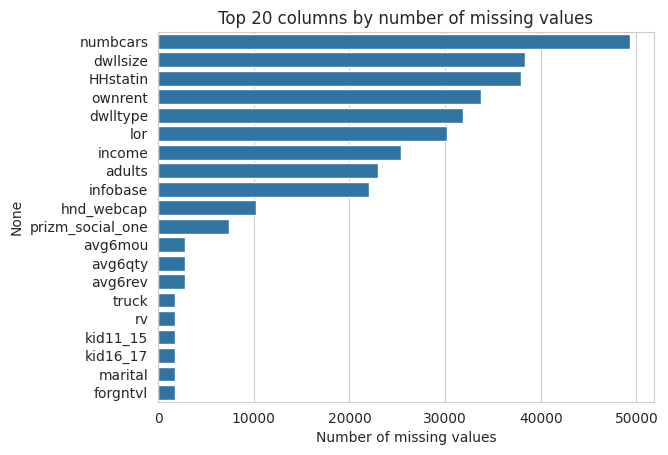

In [ ]:
# Count of missing values per column
missing_counts = df.isna().sum()

# Taking the 20 columns with the most missing values
top_missing = missing_counts.sort_values(ascending=False).head(20)

# Plot
sns.barplot(x=top_missing.values, y=top_missing.index)
plt.xlabel('Number of missing values')
plt.title('Top 20 columns by number of missing values')
plt.show()

Several variables contain missing values, although the degree of missingness varies across features. Features with excessive missing values may require imputation or removal during preprocessing.

## 3.3 Target Variable Analysis

The target variable in this dataset is `Churn`, which indicates whether a customer left the company or remained with the service.

Understanding the class distribution is important because heavily imbalanced targets can influence model evaluation and interpretation.

churn
0    50438
1    49562
Name: count, dtype: int64

churn
0    0.50438
1    0.49562
Name: proportion, dtype: float64


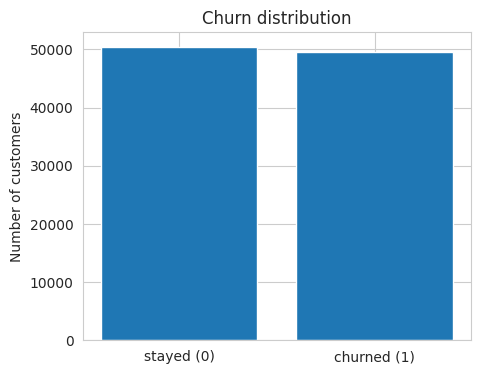

In [ ]:
# Counts and proportions
print(df['churn'].value_counts())
print()
print(df['churn'].value_counts(normalize=True))

# Bar chart
counts = df['churn'].value_counts().sort_index()
labels = ['stayed (0)', 'churned (1)']

plt.figure(figsize=(5, 4))
plt.bar(labels, counts.values)
plt.title('Churn distribution')
plt.ylabel('Number of customers')
plt.show()

Churn is near 50% — unusually balanced for telecom (real-world datasets are typically 5–10% churn). For this dataset, accuracy will be a meaningful metric, and a model that always predicts one class will score around 0.5. If you choose a different target, redo this balance check before picking your evaluation metric.

## 3.4 Numerical Feature Analysis

Exploration of:

 - revenue
 - usage
 - equipment age
 - tenure

Several numerical variables describe customer activity, revenue generation, equipment characteristics, and service usage.

Examining their distributions helps identify skewness, outliers, and unusual values that may influence model performance.

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns

print("Number of numerical columns:", len(num_cols))

Number of numerical columns: 79


In [ ]:
df[['rev_Mean',
    'mou_Mean',
    'totmrc_Mean',
    'eqpdays',
    'months']].describe()

,rev_Mean,mou_Mean,totmrc_Mean,eqpdays,months
count,99643.000000,99643.000000,99643.000000,99999.000000,100000.000000
mean,58.719985,513.559937,46.179136,391.932309,18.833990
std,46.291677,525.168140,23.623489,256.482193,9.655794
min,-6.167500,0.000000,-26.915000,-5.000000,6.000000
25%,33.260000,150.750000,30.000000,212.000000,11.000000
50%,48.195000,355.500000,44.990000,342.000000,16.000000
75%,70.750000,703.000000,59.990000,530.000000,24.000000
max,3843.262500,12206.750000,409.990000,1823.000000,61.000000


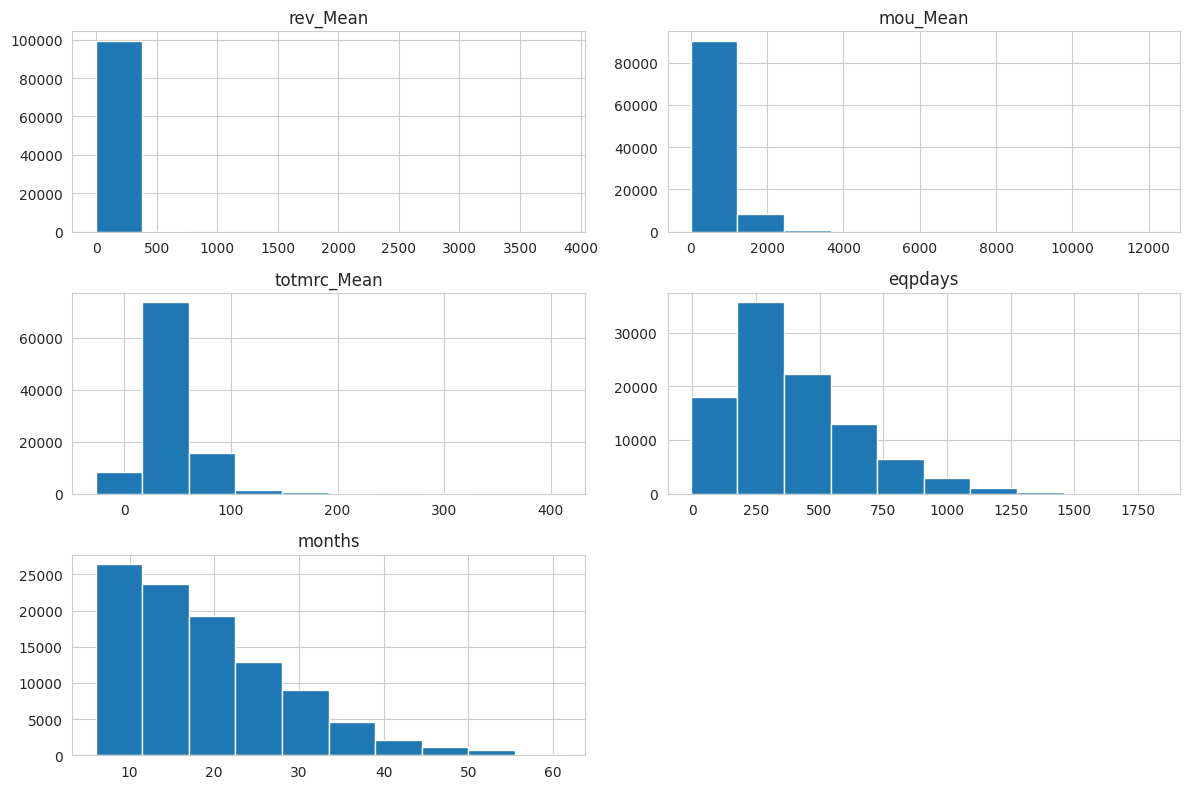

In [ ]:
df[['rev_Mean',
    'mou_Mean',
    'totmrc_Mean',
    'eqpdays',
    'months']].hist(figsize=(12,8))

plt.tight_layout()
plt.show()

Several variables show skewed distributions, particularly revenue and usage-related metrics. Equipment age and customer tenure may provide useful insights into customer retention behaviour and will be investigated further.

### 3.4.1 A Closer Look
## `equipment age` **VS** `churn`

The three checks above are dataset-wide. The real EDA work is digging into individual features — how each one relates to the target, where the differences are, and which patterns are worth following up on.

As one example: `eqpdays` records the age (in days) of each customer's current handset. Old equipment plausibly drives churn — a frustrating or outdated device makes the next contract renewal less attractive. We can check this by comparing the equipment-age distribution for churners against stayers.

Mean equipment age (stayed):  363.3 days
Mean equipment age (churned): 421.1 days


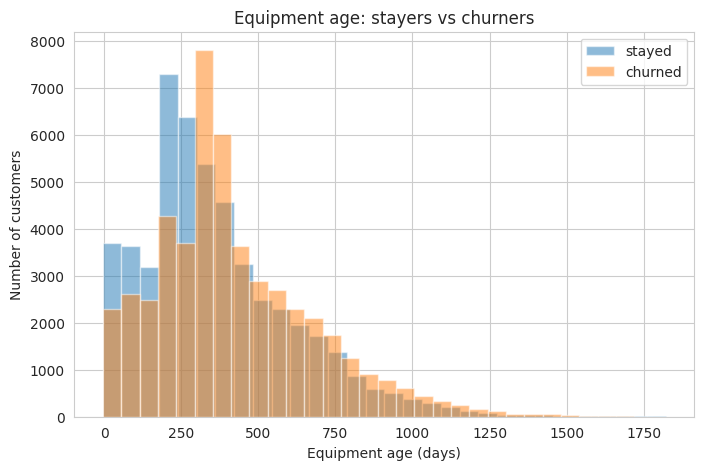

In [ ]:
# Split eqpdays into two groups based on churn
stayed = df[df['churn'] == 0]['eqpdays']
churned = df[df['churn'] == 1]['eqpdays']

# Compare the averages
print(f'Mean equipment age (stayed):  {stayed.mean():.1f} days')
print(f'Mean equipment age (churned): {churned.mean():.1f} days')

# Overlay the two distributions
plt.figure(figsize=(8, 5))
plt.hist(stayed, bins=30, alpha=0.5, label='stayed')
plt.hist(churned, bins=30, alpha=0.5, label='churned')
plt.xlabel('Equipment age (days)')
plt.ylabel('Number of customers')
plt.title('Equipment age: stayers vs churners')
plt.legend()
plt.show()

Churners skew toward older equipment — the mean and the right tail of the distribution are both higher than for stayers. That makes `eqpdays` a candidate feature for both the model and the narrative your proposal will tell ("customers with ageing handsets are at higher risk; replacing or upgrading equipment is a lever").

The point is the **exercise**: pick a candidate feature, compare it across churn classes, and decide whether it is worth following up on. Repeat this on a handful of features that look promising from the dataset overview or your domain knowledge.

## 3.5 Categorical Feature Analysis

The dataset also contains categorical variables describing customer demographics, service characteristics, and geographic information.

Understanding the distribution of these variables may reveal customer segments that behave differently.

In [ ]:
cat_cols = df.select_dtypes(include='object').columns

print("Number of categorical columns:", len(cat_cols))
print(cat_cols.tolist())

Number of categorical columns: 21
['new_cell', 'crclscod', 'asl_flag', 'prizm_social_one', 'area', 'dualband', 'refurb_new', 'hnd_webcap', 'ownrent', 'dwlltype', 'marital', 'infobase', 'HHstatin', 'dwllsize', 'ethnic', 'kid0_2', 'kid3_5', 'kid6_10', 'kid11_15', 'kid16_17', 'creditcd']


In [ ]:
df['prizm_social_one'].value_counts().head(10)

,count
prizm_social_one,
S,32097
U,23613
C,17018
T,14989
R,4895


In [ ]:
df['marital'].value_counts()

,count
marital,
U,37333
M,31052
S,17627
B,7116
A,5140


Categorical variables may contain valuable information about customer segments. These variables will later be encoded to make them suitable for machine learning models.

## 3.6 Feature Relationships with Churn

The previous analyses examined variables individually. This section investigates how selected business-relevant variables differ between customers who churned and those who remained.

The goal is to identify features that may provide predictive value and support future business recommendations.

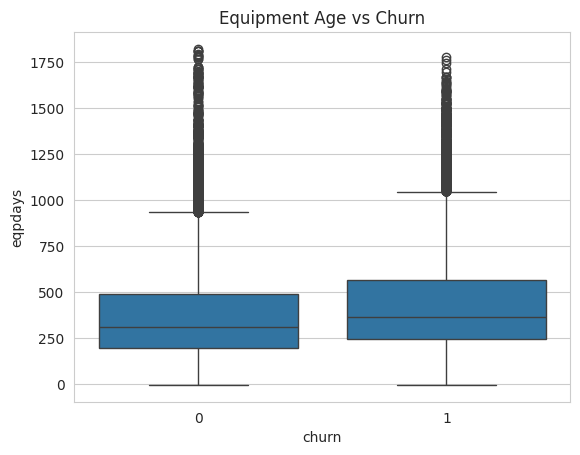

In [ ]:
sns.boxplot(x='churn', y='eqpdays', data=df)

plt.title("Equipment Age vs Churn")
plt.show()

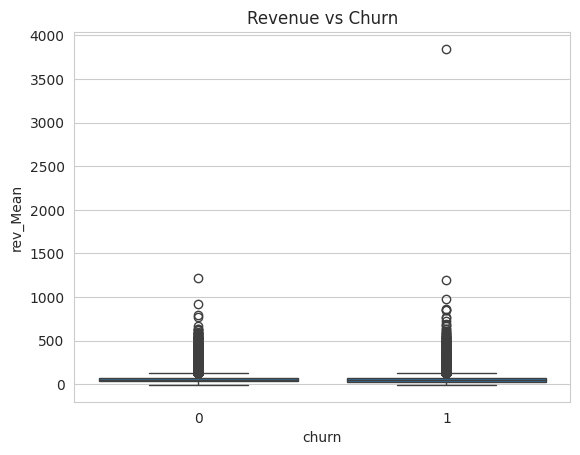

In [ ]:
sns.boxplot(x='churn', y='rev_Mean', data=df)

plt.title("Revenue vs Churn")
plt.show()

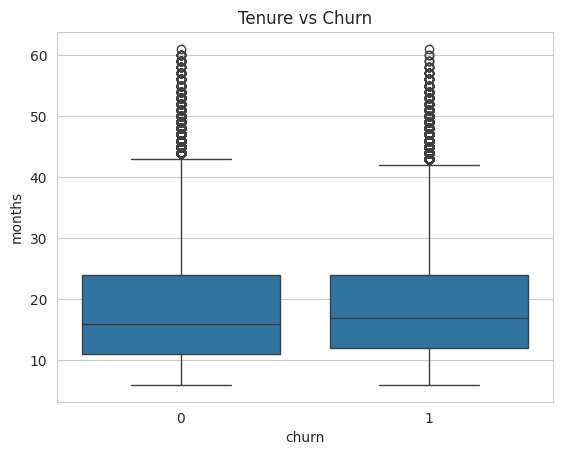

In [ ]:
sns.boxplot(x='churn', y='months', data=df)

plt.title("Tenure vs Churn")
plt.show()

Differences between churned and retained customers may indicate useful predictors. Variables showing clear separation between the two groups will be explored further during feature engineering and model development.

## 3.7 Initial Business Insights

The exploratory analysis suggests several factors may influence customer churn.

Key observations include:

- Customer behaviour varies considerably across revenue and usage levels.
- Equipment age may be associated with churn risk.
- Customer tenure appears to differ between churned and retained customers.
- Several variables contain missing values that require attention during preprocessing.

These findings provide an initial foundation for defining the business problem and selecting an appropriate machine learning approach in the next section.

# 4. Problem Definition

The telecommunications industry faces increasing competition, making customer retention an important business objective. Acquiring new customers is often more expensive than retaining existing ones, meaning customer churn can significantly impact revenue and profitability.

Based on the exploratory data analysis, customer characteristics such as service usage, revenue generation, tenure, and equipment age appear to influence churn behaviour. Therefore, this project focuses on predicting customer churn using historical customer data.

The business objective is to identify customers who are at risk of leaving the company so that targeted retention strategies can be implemented. By accurately identifying high-risk customers, Company A can improve customer retention, reduce revenue loss, and make more effective use of marketing resources.

This problem is formulated as a binary classification task where the target variable, churn, indicates whether a customer remained with the company (0) or left the company (1).

#5. Data Preprocessing


Before building **Machine Learning** models, the dataset must be prepared for analysis. Most machine learning algorithms require numerical inputs and cannot directly process text-based categorical variables.

This preprocessing stage focuses on:

1. Removing non-informative identifiers.
2. Handling categorical variables.
3. Preparing the dataset for feature engineering and modeling.

The goal is to create a clean and consistent dataset while preserving as much useful information as possible.

## 5.1 Removing Customer Identifier

Customer_ID uniquely identifies each customer but does not contain predictive information about customer behaviour. Including it may cause the model to learn customer-specific patterns that do not generalize to new data.

Therefore, the identifier column is removed before modeling.

In [ ]:
df_clean = df.drop('Customer_ID', axis=1)

print(df_clean.shape)

(100000, 99)


## 5.2 Identify Categorical Variables

Machine learning models generally require numerical inputs. Therefore, categorical variables stored as text must first be identified before encoding.

In [ ]:
cat_cols = df_clean.select_dtypes(include='object').columns

print("Categorical columns:")
print(cat_cols.tolist())

Categorical columns:
['new_cell', 'crclscod', 'asl_flag', 'prizm_social_one', 'area', 'dualband', 'refurb_new', 'hnd_webcap', 'ownrent', 'dwlltype', 'marital', 'infobase', 'HHstatin', 'dwllsize', 'ethnic', 'kid0_2', 'kid3_5', 'kid6_10', 'kid11_15', 'kid16_17', 'creditcd']


## 5.3 Encode Categorical Variables

Categorical variables are converted into numerical representations using Label Encoding. Each unique category is assigned a numerical value, allowing machine learning algorithms to process the information.

This approach is simple and effective for establishing a baseline model.

In [ ]:
df_clean = pd.get_dummies(
    df_clean,
    columns=cat_cols,
    drop_first=True
)

print("One-hot encoding completed.")

One-hot encoding completed.


In [ ]:
missing_counts = df_clean.isnull().sum()

missing_cols = missing_counts[missing_counts > 0].index

for col in missing_cols:
    df_clean[col] = df_clean[col].fillna(
        df_clean[col].median()
    )

print("Missing values handled.")

Missing values handled.


## 5.4 Verify Processed Dataset

After encoding, all variables should be stored in numerical form and ready for feature engineering and machine learning.

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Columns: 210 entries, rev_Mean to creditcd_Y
dtypes: bool(132), float64(69), int64(9)
memory usage: 72.1 MB


In [ ]:
df_clean.head()

,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,change_rev,drop_vce_Mean,drop_dat_Mean,blck_vce_Mean,blck_dat_Mean,unan_vce_Mean,unan_dat_Mean,plcd_vce_Mean,plcd_dat_Mean,recv_vce_Mean,recv_sms_Mean,comp_vce_Mean,comp_dat_Mean,custcare_Mean,ccrndmou_Mean,cc_mou_Mean,inonemin_Mean,threeway_Mean,mou_cvce_Mean,mou_cdat_Mean,mou_rvce_Mean,owylis_vce_Mean,mouowylisv_Mean,iwylis_vce_Mean,mouiwylisv_Mean,peak_vce_Mean,peak_dat_Mean,mou_peav_Mean,mou_pead_Mean,opk_vce_Mean,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months,uniqsubs,actvsubs,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev,hnd_price,phones,models,truck,rv,lor,adults,income,numbcars,forgntvl,eqpdays,new_cell_U,new_cell_Y,crclscod_A2,crclscod_A3,crclscod_AA,crclscod_B,crclscod_B2,crclscod_BA,crclscod_C,crclscod_C2,crclscod_C5,crclscod_CA,crclscod_CC,crclscod_CY,crclscod_D,crclscod_D2,crclscod_D4,crclscod_D5,crclscod_DA,crclscod_E,crclscod_E2,crclscod_E4,crclscod_EA,crclscod_EC,crclscod_EF,crclscod_EM,crclscod_G,crclscod_GA,crclscod_GY,crclscod_H,crclscod_I,crclscod_IF,crclscod_J,crclscod_JF,crclscod_K,crclscod_L,crclscod_M,crclscod_O,crclscod_P1,crclscod_S,crclscod_TP,crclscod_U,crclscod_U1,crclscod_V,crclscod_V1,crclscod_W,crclscod_Y,crclscod_Z,crclscod_Z1,crclscod_Z2,crclscod_Z4,crclscod_Z5,crclscod_ZA,crclscod_ZF,crclscod_ZY,asl_flag_Y,prizm_social_one_R,prizm_social_one_S,prizm_social_one_T,prizm_social_one_U,area_CALIFORNIA NORTH AREA,area_CENTRAL/SOUTH TEXAS AREA,area_CHICAGO AREA,area_DALLAS AREA,area_DC/MARYLAND/VIRGINIA AREA,area_GREAT LAKES AREA,area_HOUSTON AREA,area_LOS ANGELES AREA,area_MIDWEST AREA,area_NEW ENGLAND AREA,area_NEW YORK CITY AREA,area_NORTH FLORIDA AREA,area_NORTHWEST/ROCKY MOUNTAIN AREA,area_OHIO AREA,area_PHILADELPHIA AREA,area_SOUTH FLORIDA AREA,area_SOUTHWEST AREA,area_TENNESSEE AREA,dualband_T,dualband_U,dualband_Y,refurb_new_R,hnd_webcap_WC,hnd_webcap_WCMB,ownrent_R,dwlltype_S,marital_B,marital_M,marital_S,marital_U,infobase_N,HHstatin_B,HHstatin_C,HHstatin_G,HHstatin_H,HHstatin_I,dwllsize_B,dwllsize_C,dwllsize_D,dwllsize_E,dwllsize_F,dwllsize_G,dwllsize_H,dwllsize_I,dwllsize_J,dwllsize_K,dwllsize_L,dwllsize_M,dwllsize_N,dwllsize_O,ethnic_C,ethnic_D,ethnic_F,ethnic_G,ethnic_H,ethnic_I,ethnic_J,ethnic_M,ethnic_N,ethnic_O,ethnic_P,ethnic_R,ethnic_S,ethnic_U,ethnic_X,ethnic_Z,kid0_2_Y,kid3_5_Y,kid6_10_Y,kid11_15_Y,kid16_17_Y,creditcd_Y
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,-18.9975,0.666667,0.0,0.666667,0.0,6.333333,0.0,52.333333,0.0,42.333333,0.0,45.000000,0.0,0.000000,0.000000,0.000000,18.000000,0.000000,90.643333,0.0,97.176667,0.000000,0.000000,0.000000,0.000000,58.000000,0.0,132.600000,0.0,24.000000,0.0,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61,2,1,1652,4228.00000,1504.62,1453.44,4085.00,1602,29.66,83.37,32.69,272,116,30,322.0,136.0,38.0,149.98999,2.0,2.0,0.0,0.0,15.0,1.0,4.0,3.0,0.0,361.0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,True,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,50.9875,8.333333,0.0,1.000000,0.0,61.333333,0.0,263.333333,0.0,69.000000,0.0,193.333333,0.

In [ ]:
imputer = KNNImputer(n_neighbors=5)

df_clean = pd.DataFrame(
    imputer.fit_transform(df_clean),
    columns=df_clean.columns
)

In [ ]:
# Removinh columns with excessive missing values

missing_pct = df_clean.isnull().mean()

drop_cols = missing_pct[missing_pct > 0.40].index

print("Dropping:", list(drop_cols))

df_clean = df_clean.drop(columns=drop_cols)

Dropping: []


## 5.5 Preprocessing Summary

The preprocessing stage removed the customer identifier and converted categorical variables into numerical representations suitable for machine learning.

The resulting dataset is now ready for feature engineering, where additional business-oriented features can be created to improve predictive performance and provide deeper business insights.

# 6. Feature Engineering

Feature engineering involves creating new variables from existing information to capture patterns that may not be immediately visible in the raw data.

Rather than relying solely on the original features, new business-oriented variables can help improve model performance and provide additional insight into customer behaviour.

The features created in this section are designed to capture relationships between customer revenue, service usage, equipment age, and customer tenure.



In [ ]:
# Revenue per Month of Tenure
df_clean['rev_per_month'] = df_clean['rev_Mean'] / (df_clean['months'] + 1)

# Equipment Age Relative to Tenure
df_clean['eqpdays_per_month'] = df_clean['eqpdays'] / (df_clean['months'] + 1)

# Revenue per Usage Minute
df_clean['rev_per_mou'] = df_clean['rev_Mean'] / (df_clean['mou_Mean'] + 1)

# Revenue Trend
df_clean['rev_trend'] = df_clean['avg3rev'] - df_clean['avg6rev']

#Customer Activity Ratio
df_clean['active_ratio'] = df_clean['actvsubs'] / (df_clean['uniqsubs'] + 1)

In [ ]:
df_clean['mou_change'] = (
    df_clean['avg3mou']
    - df_clean['avg6mou']
)

df_clean['rev_growth_ratio'] = (
    df_clean['avg3rev']
    / (df_clean['avg6rev'] + 1)
)

df_clean['mou_growth_ratio'] = (
    df_clean['avg3mou']
    / (df_clean['avg6mou'] + 1)
)

df_clean['customer_value'] = (
    df_clean['rev_Mean']
    * df_clean['months']
)

In [ ]:
# Customer profitability

df_clean['revenue_tenure_ratio'] = (
    df_clean['rev_Mean']
    /
    (df_clean['months'] + 1)
)

# age relative to revenue

df_clean['eqpdays_rev_ratio'] = (
    df_clean['eqpdays']
    /
    (df_clean['rev_Mean'] + 1)
)

# Revenue 4rm subscription

df_clean['rev_per_active_sub'] = (
    df_clean['rev_Mean']
    /
    (df_clean['actvsubs'] + 1)
)

# Usage intensity

df_clean['mou_per_month'] = (
    df_clean['mou_Mean']
    /
    (df_clean['months'] + 1)
)

# Revenue × Usage interaction

df_clean['rev_usage_interaction'] = (
    df_clean['rev_Mean']
    *
    df_clean['mou_Mean']
)

In [ ]:
# Customer age groups

df_clean['months_bin'] = pd.cut(
    df_clean['months'],
    bins=[0,12,24,48,72,200],
    labels=False
)

# Equipment age groups

df_clean['eqpdays_bin'] = pd.cut(
    df_clean['eqpdays'],
    bins=[-1,100,300,600,1000,5000],
    labels=False
)


In [ ]:
df_clean['income_missing'] = (
    df['income'].isnull().astype(int)
)

df_clean['adults_missing'] = (
    df['adults'].isnull().astype(int)
)

df_clean['numbcars_missing'] = (
    df['numbcars'].isnull().astype(int)
)

df_clean['lor_missing'] = (
    df['lor'].isnull().astype(int)
)

## Feature Engineering Summary

Several business-oriented features were created to better represent customer value, engagement, equipment usage, and revenue patterns.

These engineered features aim to provide additional predictive information beyond the original dataset and will be included in the machine learning models developed in the next section.

# 7. Model Development

The objective of this section is to develop a machine learning model capable of predicting customer churn. The model serves as a decision-support tool that helps identify customers at risk of leaving the company.

The purpose of the model is not simply to achieve high predictive performance, but to provide evidence that can support actionable business recommendations.


### Define Features and Target

The target variable for this project is churn, where:

- 0 = Customer remains with the company
- 1 = Customer leaves the company

All remaining variables are used as predictive features.

In [ ]:
X = df_clean.drop("churn", axis=1)
y = df_clean["churn"]

cat_features = list(
    X.select_dtypes(include="object").columns
)

### CatBoost

`CatBoost` was selected as the primary model for this project because it performs particularly well on structured tabular datasets containing a mixture of numerical and categorical variables.

Unlike many algorithms, `CatBoost` can effectively model complex non-linear relationships while handling categorical features and missing values with minimal preprocessing. It also provides feature importance scores that help explain which factors contribute most strongly to customer churn.

Additionally, `CatBoost` has demonstrated strong performance in many real-world business analytics applications and serves as a suitable balance between predictive power and interpretability.

### Train-Test Split

The dataset is divided into training and testing sets. The model is trained using the training data and evaluated on previously unseen testing data.

A stratified split is used to preserve the original churn distribution in both datasets. This ensures that both churned and non-churned customers remain proportionally represented during training and evaluation.

A random_seed=52 value is specified to ensure reproducibility. Using the same random seed allows the analysis to produce consistent results when the notebook is rerun.

## Training

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=52
)

# Replacing infinite values with NaN in both sets
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

# NaN values
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

from catboost import CatBoostClassifier

model = CatBoostClassifier(
    iterations=1200,
    depth=8,
    learning_rate=0.03,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=52,
    l2_leaf_reg=5,
    subsample=0.8,
    verbose=100
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_features
)

y_pred = model.predict(X_test)

y_proba = model.predict_proba(
    X_test
)[:,1]

test_auc = roc_auc_score(
    y_test,
    y_proba
)

train_proba = model.predict_proba(X_train)[:,1]

train_auc = roc_auc_score(
    y_train,
    train_proba
)

print("Train AUC:", train_auc)
print("Test AUC:", test_auc)

0:	total: 348ms	remaining: 6m 56s
100:	total: 20.3s	remaining: 3m 41s
200:	total: 35.8s	remaining: 2m 58s
300:	total: 51.1s	remaining: 2m 32s
400:	total: 1m 6s	remaining: 2m 11s
500:	total: 1m 21s	remaining: 1m 53s
600:	total: 1m 37s	remaining: 1m 37s
700:	total: 1m 52s	remaining: 1m 20s
800:	total: 2m 7s	remaining: 1m 3s
900:	total: 2m 22s	remaining: 47.3s
1000:	total: 2m 37s	remaining: 31.4s
1100:	total: 2m 53s	remaining: 15.6s
1199:	total: 3m 8s	remaining: 0us
Train AUC: 0.8347671974885578
Test AUC: 0.7021149117787682


In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.get_feature_importance()
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

display(feature_importance.head(20))

,Feature,Importance
9,change_mou,6.215523
48,months,4.986133
2,totmrc_Mean,4.006963
76,eqpdays,3.308302
10,change_rev,3.170310
211,rev_per_mou,2.456689
66,hnd_price,2.346494
216,mou_growth_ratio,2.214973
59,avgqty,1.885746
210,eqpdays_per_month,1.871961


In [ ]:
from sklearn.model_selection import cross_val_score

cv_auc = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="roc_auc"
)

print("CV AUC")
print(cv_auc)
print(cv_auc.mean())

0:	total: 317ms	remaining: 6m 20s
100:	total: 17.6s	remaining: 3m 11s
200:	total: 33.2s	remaining: 2m 44s
300:	total: 49.3s	remaining: 2m 27s
400:	total: 1m 4s	remaining: 2m 8s
500:	total: 1m 19s	remaining: 1m 51s
600:	total: 1m 35s	remaining: 1m 34s
700:	total: 1m 50s	remaining: 1m 18s
800:	total: 2m 5s	remaining: 1m 2s
900:	total: 2m 20s	remaining: 46.7s
1000:	total: 2m 35s	remaining: 30.9s
1100:	total: 2m 50s	remaining: 15.4s
1199:	total: 3m 5s	remaining: 0us
0:	total: 157ms	remaining: 3m 8s
100:	total: 16.2s	remaining: 2m 56s
200:	total: 31.6s	remaining: 2m 37s
300:	total: 47s	remaining: 2m 20s
400:	total: 1m 2s	remaining: 2m 3s
500:	total: 1m 17s	remaining: 1m 47s
600:	total: 1m 32s	remaining: 1m 32s
700:	total: 1m 48s	remaining: 1m 17s
800:	total: 2m 3s	remaining: 1m 1s
900:	total: 2m 18s	remaining: 45.9s
1000:	total: 2m 33s	remaining: 30.6s
1100:	total: 2m 48s	remaining: 15.2s
1199:	total: 3m 3s	remaining: 0us
0:	total: 161ms	remaining: 3m 13s
100:	total: 16.4s	remaining: 2m 58s

In [ ]:
auc = roc_auc_score(
    y_test,
    y_proba
)

print("AUC:", auc)

AUC: 0.7021149117787682


# 8. Model Evaluation

After training the model, its performance must be evaluated on unseen data.

Several evaluation metrics are used to assess how effectively the model distinguishes between customers who churn and those who remain with the company.

## 8.1 Accuracy

Accuracy measures the proportion of correctly classified observations. Since the churn classes are relatively balanced, accuracy provides a useful initial indicator of model performance.

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.6440


## 8.2 Area Under the ROC Curve (AUC)

AUC measures the model's ability to distinguish between churned and non-churned customers across different classification thresholds.

Higher AUC values indicate stronger discriminatory performance.

In [ ]:
auc = roc_auc_score(y_test, y_proba)
print(f'AUC: {auc:.4f}')

AUC: 0.7021


## 8.3 Confusion Matrix

The confusion matrix provides a detailed breakdown of correct and incorrect predictions.

This helps identify the types of errors made by the model and their potential business implications.

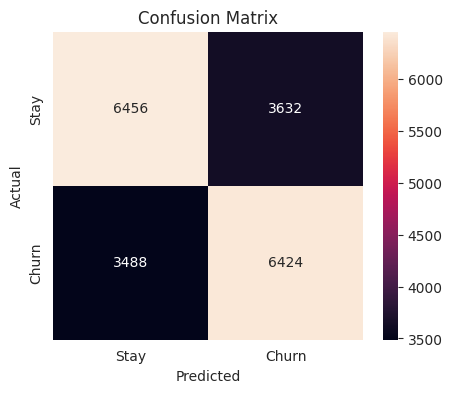

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Stay','Churn'],
    yticklabels=['Stay','Churn']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

## 8.4 ROC Curve

The ROC Curve visualizes the trade-off between the true positive rate and false positive rate across different classification thresholds.

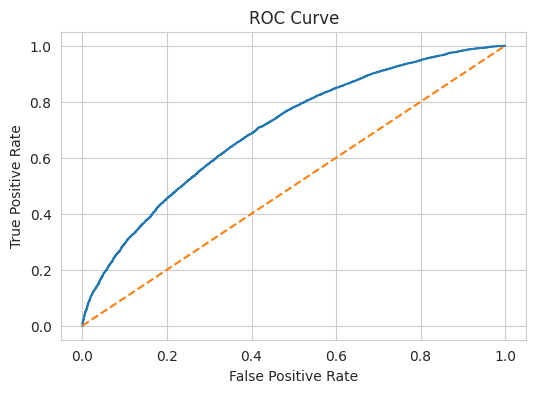

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(6,4))

plt.plot(fpr, tpr)

plt.plot([0,1],[0,1],'--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

plt.show()

## 8.5 Feature Importance

Feature importance helps identify which variables contribute most strongly to churn prediction.

Understanding these drivers is essential for converting model outputs into actionable business recommendations.

# 9. Business Insights

The model evaluation and feature importance analysis reveal several factors that influence customer churn.

Features related to customer usage patterns, revenue generation, customer tenure, and equipment characteristics appear to contribute most strongly to churn prediction.

These findings suggest that customer churn is not driven by a single factor but rather by a combination of customer engagement, service usage, and customer lifecycle characteristics.

The insights obtained from the model provide a foundation for developing targeted business strategies aimed at improving customer retention.

# 10. Business Proposal

The machine learning model provides a churn probability score for each customer. However, the score itself is not the final recommendation. The business value comes from using these predictions to guide targeted interventions.

## Proposed Strategy

Company A should rank customers according to their predicted churn probability and focus retention efforts on the highest-risk segment.

For this proposal, customers in the top 10% of predicted churn scores are classified as high-risk customers and become the target group for intervention.

## Recommended Intervention

The recommended intervention consists of:

- Personalized retention offers
- Device upgrade promotions
- Loyalty rewards
- Dedicated customer support follow-ups

These actions are designed to increase customer satisfaction and reduce the likelihood of customer departure.

## Estimated Business Impact

To estimate the potential business value, the following assumptions are made:

- Top 10% highest-risk customers are targeted.
- Average annual revenue per customer = $500.
- Retention campaign cost = $50 per customer.
- Intervention success rate = 20%.

Under these assumptions:

Revenue retained

= (Targeted Customers × Success Rate × Average Revenue)

Campaign Cost

= (Targeted Customers × Cost per Customer)

Net Benefit

= Revenue Retained − Campaign Cost

This framework allows Company A to estimate the financial impact of different retention strategies and optimize campaign spending.

## Risks and Limitations

Several factors may influence the actual effectiveness of the proposal:

- Customer behaviour may change over time.
- Competitor actions are not captured in the dataset.
- Not all customers will respond positively to interventions.
- The model may incorrectly classify some customers.

Despite these limitations, the proposed strategy provides a data-driven approach for prioritizing customer retention efforts and allocating resources more efficiently.

# 11. Conclusion

This project explored customer churn within Company A using exploratory data analysis, feature engineering, and machine learning techniques.

The analysis identified several customer characteristics associated with churn and demonstrated that machine learning can effectively support churn prediction. An XGBoost classification model was developed and evaluated using multiple performance metrics, providing evidence that meaningful predictive patterns exist within the data.

Based on these findings, a proactive customer retention strategy was proposed to help Company A reduce churn and improve long-term customer value.

Overall, this project demonstrates how data-driven decision making can support strategic business objectives and improve competitiveness within the telecommunications industry.